In [146]:
import yfinance as yf

# load data
t = yf.download(
    "AAPL",
    start = "1960-01-01",  
    end = "2025-08-31", 
    auto_adjust = True
    )

# restructure data
t = t.droplevel(level='Ticker', axis=1)

# rename columns
t.rename(
    columns = {
        'Open':'o', 
        'High':'h', 
        'Low':'l', 
        'Close':'c', 
        'Volume':'v'
    }, 
    inplace = True)

#next close
t.loc[:,'nc'] = t.c.shift(-1)

# future price change
t.loc[:, 'fpc'] = 100.0 * (t.nc/t.c - 1)











[*********************100%***********************]  1 of 1 completed


In [147]:
import pandas_ta as ta

# Momentum
t['f0'] = ta.rsi(t.c, length=14)
st = ta.stoch(t.h, t.l, t.c)
t['f1'] = st.STOCHk_14_3_3
t['f2'] = st.STOCHd_14_3_3
t['f3'] = ta.roc(t.c, length=10)

# Trend
t['f4'] = ta.ema(t.c, length=10)
t['f5'] = ta.ema(t.c, length=50)
macd = ta.macd(t.c)
t['f6'] = macd.MACD_12_26_9
t['f7'] = macd.MACDs_12_26_9
t['f8'] = ta.adx(t.h, t.l, t.c).ADX_14

# Volatility
t['f9'] = ta.atr(t.h, t.l, t.c, length=14)
bb = ta.bbands(t.c, length=20, std=2)
t['f10'] = bb['BBP_20_2.0']
t['f11'] = bb['BBB_20_2.0']

# Volume / Flow
t['f12'] = ta.obv(t.c, t.v) / 1e9
t['f13'] = ta.mfi(
    t.h, t.l, t.c, t.v, length=14)
t['f14'] = ta.vwap(t.h, t.l, t.c, t.v)










/var/folders/s1/fwkx4m816qb85j8vnrlygx7m0000gq/T/ipykernel_26310/2606647133.py:26: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[7.67419713e+06 6.70952374e+06 4.71301121e+06 ... 9.66030120e+09
 7.05061754e+09 1.24222942e+10]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  t['f13'] = ta.mfi(
/var/folders/s1/fwkx4m816qb85j8vnrlygx7m0000gq/T/ipykernel_26310/2606647133.py:26: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.64433922e+07 9.16007056e+06 8.29767998e+06 ... 9.09911106e+09
 9.61151526e+09 6.89181138e+09]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  t['f13'] = ta.mfi(


In [46]:
feats = [f'f{i}' for i in range(15)]

# leave only features and price changes
t = t[feats + ['fpc']].dropna()

# delete rows where price change is zero
t = t[t.fpc != 0.0]

# define targets and weights
t.loc[:,'y'] = 1 / t.fpc
t.loc[:,'w'] = t.fpc ** 2

n = len(t) // 2

# split data chronologically
t1 = t.head(n - 30)
t2 = t.tail(n - 30)

# features
X1 = t1[feats].values
X2 = t2[feats].values

# targets
y1 = t1.y.values
y2 = t2.y.values

# weights
w1 = t1.w.values
w2 = t2.w.values

# price changes
c1 = t1.fpc.values
c2 = t2.fpc.values






In [253]:
from sklearn import ensemble as ens

# specify the model
m = ens.GradientBoostingRegressor(
    loss = "squared_error",
    learning_rate = 0.0075,
    n_estimators = 50,
    max_depth = 1,
    min_samples_leaf = 250,
    min_samples_split = 500,
    subsample = 0.5,
    max_features = 0.4,
    random_state = 42,
    n_iter_no_change = None,
)


# fit / train the model
m.fit(X1, y1, sample_weight = w1)

# predict in- and out-of-samples
p1 = m.predict(X1)
p2 = m.predict(X2)

# calculate profits as
# price changes multiplied by positions
pr1 = c1 * p1
pr2 = c2 * p2








In [257]:
import numpy as np

# Sharpe ratio
def get_sharpe(x):
    m = np.mean(x)
    s = np.std(x)
    r = m / s
    k = np.sqrt(252)
    return k * m / s

# Sharpe ratios in- and out-of-sample
s1 = get_sharpe(pr1)
s2 = get_sharpe(pr2)

# Share ratios of constant model
s1_ref = get_sharpe(c1)
s2_ref = get_sharpe(c2)

print('In-sample:')
print('Constant Model:', round(s1_ref,2))
print('Our Model:', round(s1,2), '\n')

print('Out-of-sample:')
print('Constant Model:', round(s2_ref,2))
print('Our Model:', round(s2,2), '\n'*5)


In-sample:
Constant Model: 0.4
Our Model: 0.75 

Out-of-sample:
Constant Model: 1.08
Our Model: 1.25 







In [276]:
from numpy.random import permutation as prm

ref_sharpe = get_sharpe(c2 * p2)

n_tries = 100_000

fake_sharpes = np.array([
    get_sharpe(c2 * prm(p2))
    for _ in range(n_tries)
])

n = (fake_sharpes > ref_sharpe).sum()
print(f'\n{n} times out of {n_tries}\n')

perc = 100.0 * n / n_tries
print(perc, '%', '\n'*20)


26 times out of 100000

0.026 % 






















In [324]:
slpg = 0.02

pr2_slpg = c2 * p2 

pr2_slpg -= slpg * np.abs(
    np.diff(p2, prepend=0)
    )

srp_slpg = get_sharpe(pr2_slpg)

print('\nSharpe Ratio with Slippage:')
print(round(srp_slpg,2), '\n'*20)



Sharpe Ratio with Slippage:
1.24 






















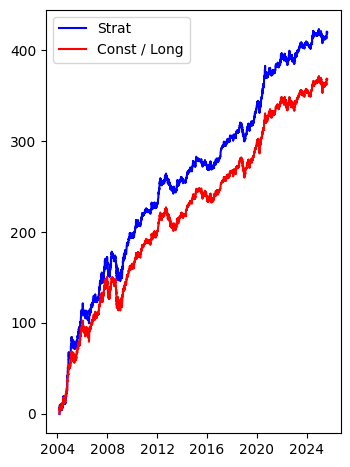

In [328]:
import matplotlib.pyplot as plt
plt.figure(figsize = (3.8 ,5.5))
plt.plot(t2.index,
    np.cumsum(pr2_slpg)/np.std(pr2_slpg), 
    color = 'b', label = 'Strat')
plt.plot(t2.index,np.cumsum(c2)/np.std(c2), 
    color = 'r', label = 'Const / Long')
plt.legend(); plt.show()

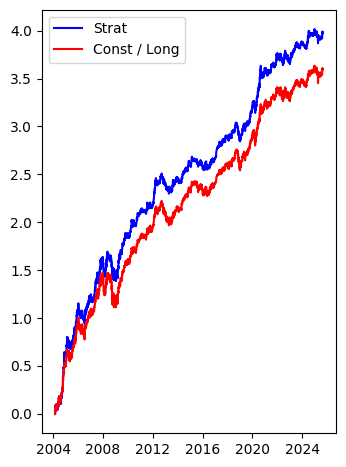

In [316]:
import matplotlib.pyplot as plt
plt.figure(figsize = (3.8 ,5.5))
plt.plot(t2.index,np.cumsum(pr2_slpg), 
    color = 'b', label = 'Strat')
plt.plot(t2.index,np.cumsum(c2*np.mean(p2)), 
    color = 'r', label = 'Const / Long')
plt.legend()
plt.show()

In [299]:
get_sharpe(c2), get_sharpe(pr2), get_sharpe(pr2_slpg)

(1.084019022371873, 1.2485664946622617, 1.2612894248688287)

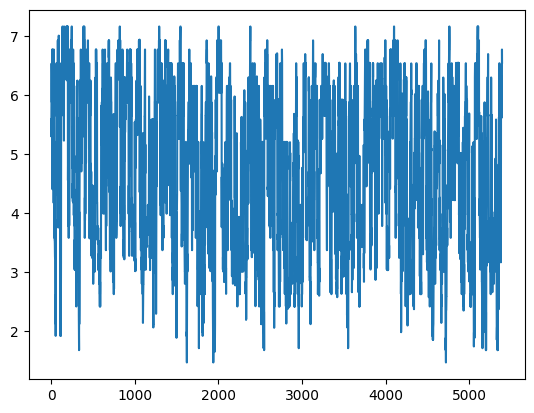

In [301]:
plt.plot(p2*1000.0)

In [79]:
from sklearn import ensemble as en


from sklearn.linear_model import LinearRegression

m = en.HistGradientBoostingRegressor(
    loss = "squared_error",
    max_depth = 4,
    learning_rate = 0.05,
    max_iter = 500,
    min_samples_leaf = 20,
    l2_regularization = 1.0,
    random_state = 42
)

m = en.HistGradientBoostingRegressor(
    loss="squared_error",
    max_depth=3,             # shallower trees
    learning_rate=0.02,      # smaller steps
    max_iter=300,            # fewer iterations
    min_samples_leaf=50,     # stronger smoothing
    l2_regularization=5.0,   # heavier penalty
    max_bins=128,            # less granularity
    early_stopping=True,
    validation_fraction=0.1,
    random_state=2
)


from sklearn.ensemble import RandomForestRegressor

m = RandomForestRegressor(
    n_estimators=500,
    max_depth=2,          # limit depth
    min_samples_leaf=20,  # regularization
    max_features="sqrt",  # feature subsampling
    random_state=42
)

m = en.HistGradientBoostingRegressor(
    loss="squared_error",
    max_depth=1,
    max_leaf_nodes=7,
    learning_rate=0.01,
    max_iter=150,
    min_samples_leaf=200,
    l2_regularization=50.0,
    max_bins=64,
    early_stopping=True,
    validation_fraction=0.2,
    random_state=42
)


m = en.RandomForestRegressor(
    n_estimators=300,          # enough trees for stability
    criterion="squared_error", # MSE
    max_depth=1,               # very shallow
    max_leaf_nodes=8,          # hard cap on complexity
    min_samples_leaf=100,      # each leaf must have lots of data
    min_samples_split=200,     # discourage tiny splits
    max_features=5,            # ~sqrt(15)=~4; keep small to reduce variance
    bootstrap=True,
    max_samples=0.5,           # row subsampling
    oob_score=True,            # quick sanity check (not a time-series CV substitute)
    random_state=42,
    n_jobs=-1
)



from xgboost import XGBRegressor

m = XGBRegressor(
    objective="reg:squarederror",  # MSE
    n_estimators=400,              # more trees + small steps
    learning_rate=0.03,            # small
    max_depth=2,                   # shallow trees
    min_child_weight=20,           # need a lot of weight to split
    subsample=0.6,                 # row subsampling
    colsample_bytree=0.5,          # feature subsampling
    colsample_bylevel=0.8,
    reg_lambda=20.0,               # L2
    reg_alpha=2.0,                 # L1
    tree_method="hist",            # fast & stable
    max_bin=128,
    random_state=12,
    n_jobs=-1
)


#m = LinearRegression()

m.fit(X1, y1, sample_weight = w1)
p1 = m.predict(X1)
p2 = m.predict(X2)

pr1 = c1 * p1
pr2 = c2 * p2

import numpy as np

def get_sharpe(x):
    m = np.mean(x)
    s = np.std(x)
    r = m / s
    k = np.sqrt(252)
    return k * m / s

s1 = get_sharpe(pr1)
s2 = get_sharpe(pr2)

print(get_sharpe(c1), get_sharpe(pr1))
print(get_sharpe(c2), get_sharpe(pr2))

0.39933181576593296 4.306397614686972
1.084019022371873 -0.7767221360914989


In [45]:
w1.min()

-127.14619753089687

In [102]:
from sklearn.ensemble import RandomForestRegressor

m = RandomForestRegressor(
    n_estimators=600,
    criterion="squared_error",
    max_depth=2,          # decision stumps + 1 split
    max_leaf_nodes=6,     # hard cap on complexity
    min_samples_leaf=250, # lots of data per leaf
    min_samples_split=500,
    max_features=3,       # strong feature subsampling
    bootstrap=True,
    max_samples=0.5,      # row subsampling
    random_state=6,
    n_jobs=-1
)

#----
from sklearn.ensemble import GradientBoostingRegressor

m = GradientBoostingRegressor(
    loss="squared_error",
    learning_rate=0.01,
    n_estimators=800,
    max_depth=1,          # decision stumps
    min_samples_leaf=200, # large leaves
    min_samples_split=400,
    subsample=0.6,        # row subsampling
    max_features=0.5,     # feature subsampling
    random_state=12, # 12
    n_iter_no_change=30,  # early stopping on a holdout slice of X1
    validation_fraction=0.2,
    tol=1e-4
)

#----------

m = GradientBoostingRegressor(
    loss="squared_error",
    learning_rate=0.0075,
    n_estimators=1400,
    max_depth=1,           # stumps
    min_samples_leaf=250,  # bigger leaves
    min_samples_split=500,
    subsample=0.5,         # stronger bagging
    max_features=0.4,      # stronger feature subsampling
    random_state=12,
    n_iter_no_change=50,
    validation_fraction=0.25,
    tol=1e-4
)

#---

m.fit(X1, y1, sample_weight=w1)

p1 = m.predict(X1)
p2 = m.predict(X2)


m.fit(X1s, y1, sample_weight = w1)
p1 = m.predict(X1s)
p2 = m.predict(X2s)

pr1 = c1 * p1
pr2 = c2 * p2

import numpy as np

def get_sharpe(x):
    m = np.mean(x)
    s = np.std(x)
    r = m / s
    k = np.sqrt(252)
    return k * m / s

s1 = get_sharpe(pr1)
s2 = get_sharpe(pr2)

print(get_sharpe(c1), get_sharpe(pr1))
print(get_sharpe(c2), get_sharpe(pr2))

0.39933181576593296 0.7408766118699327
1.084019022371873 1.2768899953099084


In [105]:
p2[:5]

array([0.00629358, 0.00603482, 0.00686069, 0.006286  , 0.00608517])

1.2945550159821657
3


In [139]:
slippage_bps = 0.02
pr2_slpg = c2 * p2 - slippage_bps * np.abs(np.diff(p2, prepend=0))

In [140]:
get_sharpe(pr2_slpg), get_sharpe(pr2)

(1.2612894248688287, 1.2768899953099084)

In [141]:
import matplotlib.pyplot as plt

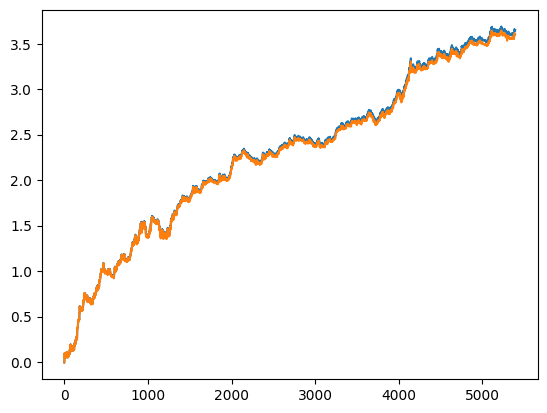

In [142]:
plt.plot(np.cumsum(pr2))
plt.plot(np.cumsum(pr2_slpg))

In [329]:
9 + 4 + 10 + 10 + 8 + 12 + 9 + 11 + 13

86

In [345]:
ls = [8.74, 3.6000000000000005, 8.96, 9.06, 7.0600000000000005, 11.69, 8.72, 6.890000000000001 + 6.99]

ls = [8.94,
3.8000000000000007,
9.16,
9.26,
7.260000000000001,
11.889999999999999,
8.92,
7.090000000000001 +
7.19]

s = sum(ls)
print(s)

73.50999999999999


In [346]:
f = 59.0 / s
f

0.8026118895388383

In [347]:
for e, x in enumerate(ls):
    print(f'dt_{e+1} = {x*f}')

dt_1 = 7.175350292477214
dt_2 = 3.049925180247586
dt_3 = 7.351924908175759
dt_4 = 7.432186097129643
dt_5 = 5.826962318051967
dt_6 = 9.543055366616787
dt_7 = 7.159298054686438
dt_8 = 11.461297782614611
